# Notebook 5 — Retention Strength Assessment
**European Bank Customer Churn Analysis**

> Define sticky customer profiles, measure churn stability across engagement tiers, identify engagement thresholds linked to retention, and summarise all findings.

---

## Setup & Data Load

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F7',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid':        True,
    'grid.color':       '#E8E6DE',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

PALETTE = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'amber':  '#EF9F27',
    'coral':  '#D85A30',
    'purple': '#7F77DD',
    'red':    '#E24B4A',
    'gray':   '#888780',
    'green':  '#639922',
    'pink':   '#D4537E',
}
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('European_Bank.csv')
churn_rate = df['Exited'].mean() * 100
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns  |  Churn rate: {churn_rate:.1f}%')

Loaded: 10,000 rows × 14 columns  |  Churn rate: 20.4%


In [3]:
# ── Pre-compute shared fields ──────────────────────────────────────────────
HIGH_BALANCE_THRESHOLD = df['Balance'].quantile(0.75)
BALANCE_THRESHOLD      = df[df['Balance'] > 0]['Balance'].median()

# Engagement profile
def classify_engagement(row):
    active   = row['IsActiveMember'] == 1
    multi    = row['NumOfProducts']  >= 2
    high_bal = row['Balance'] >= HIGH_BALANCE_THRESHOLD and row['Balance'] > 0
    if active and multi:               return 'Active Engaged'
    elif not active and not multi and row['Balance'] == 0: return 'Inactive Disengaged'
    elif active and not multi:         return 'Active Low-Product'
    elif not active and high_bal:      return 'Inactive High-Balance'
    else:                              return 'Mixed'

df['EngagementProfile']    = df.apply(classify_engagement, axis=1)
df['ProductTier']          = df['NumOfProducts'].apply(
    lambda x: 'Single (1)' if x == 1 else ('Dual (2)' if x == 2 else 'Power (3-4)'))

salary_75  = df['EstimatedSalary'].quantile(0.75)
balance_25 = df[df['Balance'] > 0]['Balance'].quantile(0.25)
df['SalaryBalanceMismatch'] = (
    (df['EstimatedSalary'] >= salary_75) &
    ((df['Balance'] == 0) | (df['Balance'] < balance_25))
)
bal_75 = df['Balance'].quantile(0.75)
sal_75 = df['EstimatedSalary'].quantile(0.75)
df['IsPremium']       = (df['Balance'] >= bal_75) & (df['EstimatedSalary'] >= sal_75)
df['IsAtRiskPremium'] = df['IsPremium'] & (df['IsActiveMember'] == 0)

def sticky_score(row):
    s = 0
    if row['IsActiveMember'] == 1:        s += 2
    if row['NumOfProducts'] >= 2:          s += 2
    if row['HasCrCard'] == 1:              s += 1
    if row['Balance'] > BALANCE_THRESHOLD: s += 2
    if row['Tenure'] >= 5:                 s += 1
    if row['CreditScore'] >= 700:          s += 1
    return s
df['StickyScore'] = df.apply(sticky_score, axis=1)
df['StickyTier']  = pd.cut(df['StickyScore'], bins=[-1,2,5,7,9],
    labels=['Low (0-2)','Medium (3-5)','High (6-7)','Very High (8-9)'])

print('Shared features computed ✓')

Shared features computed ✓


## 5.1 — Sticky Score Composition

In [4]:
sticky_stats = df.groupby('StickyTier', observed=True).agg(
    Count       = ('Exited', 'count'),
    Churn_Rate  = ('Exited', 'mean'),
    Avg_Balance = ('Balance', 'mean'),
    Avg_Products= ('NumOfProducts','mean')
).reset_index()
sticky_stats['Churn_Pct']    = sticky_stats['Churn_Rate'] * 100
sticky_stats['Retention_Pct']= 100 - sticky_stats['Churn_Pct']

print('Sticky Score Composition (max = 9 pts)')
print('─' * 42)
print('  Active Member    : 2 pts')
print('  ≥2 Products      : 2 pts')
print('  Has Credit Card  : 1 pt')
print('  High Balance     : 2 pts')
print('  Tenure ≥5 yrs    : 1 pt')
print('  Credit Score ≥700: 1 pt')
print()
print(sticky_stats[['StickyTier','Count','Churn_Pct','Retention_Pct','Avg_Balance','Avg_Products']].to_string(index=False))

Sticky Score Composition (max = 9 pts)
──────────────────────────────────────────
  Active Member    : 2 pts
  ≥2 Products      : 2 pts
  Has Credit Card  : 1 pt
  High Balance     : 2 pts
  Tenure ≥5 yrs    : 1 pt
  Credit Score ≥700: 1 pt

     StickyTier  Count  Churn_Pct  Retention_Pct   Avg_Balance  Avg_Products
      Low (0-2)   1685  33.946588      66.053412  66748.076694      1.102671
   Medium (3-5)   5789  19.174296      80.825704  72221.110062      1.514942
     High (6-7)   2211  13.839891      86.160109  85587.003623      1.814564
Very High (8-9)    315  15.555556      84.444444 143071.468222      2.101587


## 5.2 — Churn Stability Across Engagement Tiers

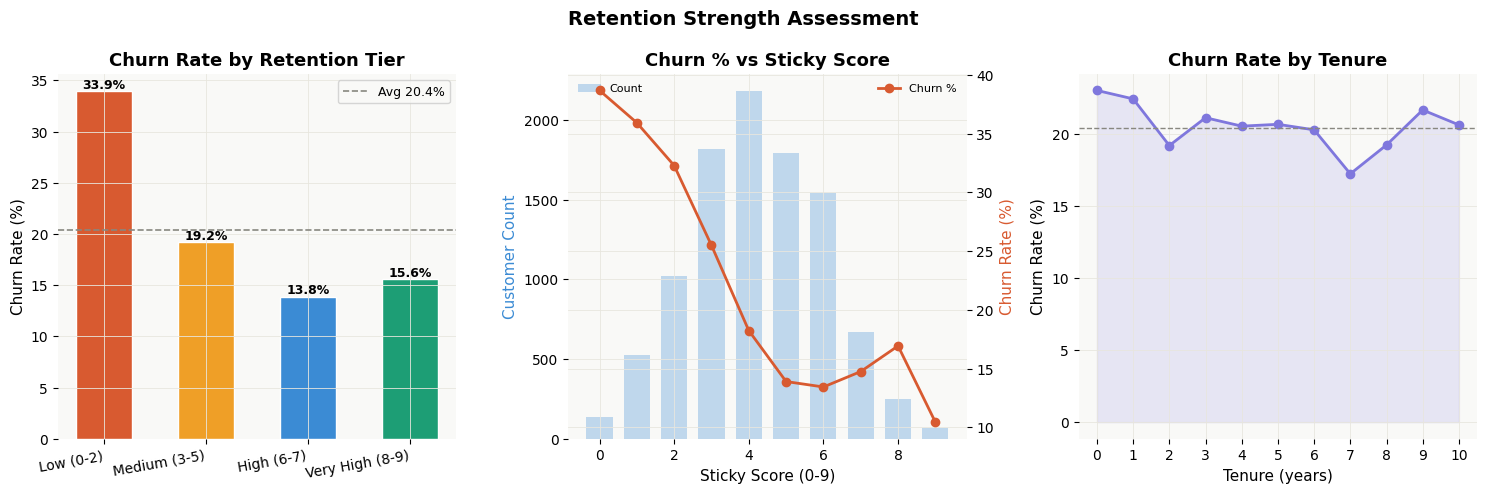

In [5]:
tier_colors = [PALETTE['coral'], PALETTE['amber'], PALETTE['blue'], PALETTE['teal']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Retention Strength Assessment', fontweight='bold', fontsize=14)

# Churn rate by sticky tier
ax = axes[0]
bars = ax.bar(sticky_stats['StickyTier'], sticky_stats['Churn_Pct'],
              color=tier_colors, width=0.55, edgecolor='white')
ax.axhline(churn_rate, color=PALETTE['gray'], linestyle='--', linewidth=1.2,
           label=f'Avg {churn_rate:.1f}%')
ax.set_title('Churn Rate by Retention Tier'); ax.set_ylabel('Churn Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=10, ha='right'); ax.legend(fontsize=9)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# Score vs churn
ax2 = axes[1]
score_churn = df.groupby('StickyScore')['Exited'].mean() * 100
score_count = df.groupby('StickyScore')['Exited'].count()
ax2_twin = ax2.twinx()
ax2.bar(score_count.index, score_count.values,
        color=PALETTE['blue'], alpha=0.3, width=0.7, label='Count')
ax2_twin.plot(score_churn.index, score_churn.values,
              'o-', color=PALETTE['coral'], linewidth=2, markersize=6, label='Churn %')
ax2.set_title('Churn % vs Sticky Score'); ax2.set_xlabel('Sticky Score (0-9)')
ax2.set_ylabel('Customer Count', color=PALETTE['blue'])
ax2_twin.set_ylabel('Churn Rate (%)', color=PALETTE['coral'])
ax2.legend(loc='upper left', fontsize=8, frameon=False)
ax2_twin.legend(loc='upper right', fontsize=8, frameon=False)

# Tenure churn trend
ax3 = axes[2]
tenure_churn = df.groupby('Tenure')['Exited'].agg(['mean','count']).reset_index()
tenure_churn['Churn_Pct'] = tenure_churn['mean'] * 100
ax3.plot(tenure_churn['Tenure'], tenure_churn['Churn_Pct'],
         'o-', color=PALETTE['purple'], linewidth=2, markersize=6)
ax3.axhline(churn_rate, color=PALETTE['gray'], linestyle='--', linewidth=1)
ax3.fill_between(tenure_churn['Tenure'], tenure_churn['Churn_Pct'], alpha=0.15, color=PALETTE['purple'])
ax3.set_title('Churn Rate by Tenure'); ax3.set_xlabel('Tenure (years)')
ax3.set_ylabel('Churn Rate (%)'); ax3.set_xticks(range(0, 11))

plt.tight_layout()
plt.savefig('fig_11_retention_strength.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.3 — Engagement Thresholds Linked to Retention

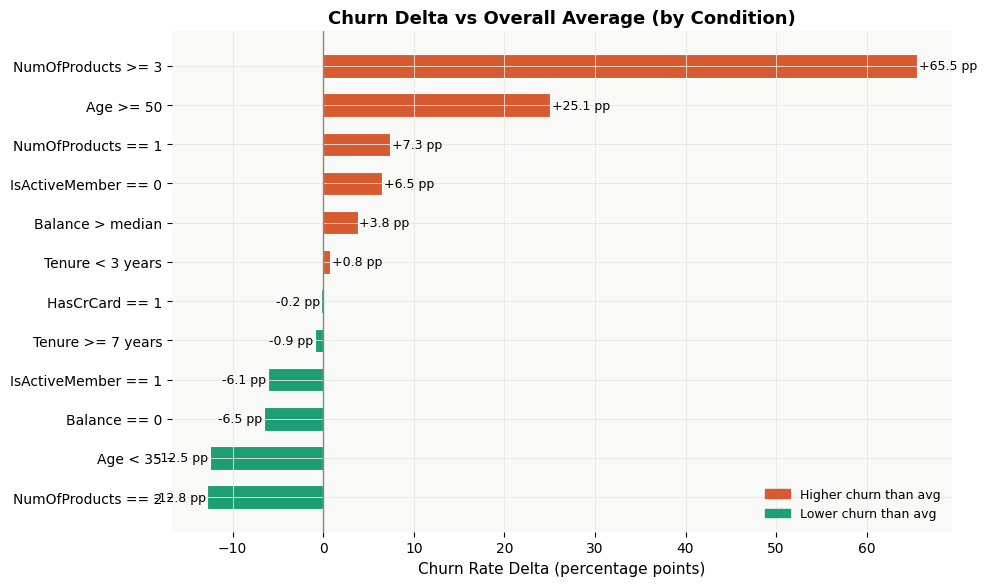

          Condition    N  Churn%  vs_Avg
 NumOfProducts >= 3  326    85.9    65.5
          Age >= 50 1395    45.4    25.1
 NumOfProducts == 1 5084    27.7     7.3
IsActiveMember == 0 4849    26.9     6.5
   Balance > median 3191    24.2     3.8
   Tenure < 3 years 2496    21.2     0.8
     HasCrCard == 1 7055    20.2    -0.2
  Tenure >= 7 years 3527    19.5    -0.9
IsActiveMember == 1 5151    14.3    -6.1
       Balance == 0 3617    13.8    -6.5
           Age < 35 3679     7.9   -12.5
 NumOfProducts == 2 4590     7.6   -12.8


In [6]:
factors = [
    ('IsActiveMember == 1',                  df['IsActiveMember'] == 1),
    ('IsActiveMember == 0',                  df['IsActiveMember'] == 0),
    ('NumOfProducts == 1',                   df['NumOfProducts'] == 1),
    ('NumOfProducts == 2',                   df['NumOfProducts'] == 2),
    ('NumOfProducts >= 3',                   df['NumOfProducts'] >= 3),
    ('HasCrCard == 1',                       df['HasCrCard'] == 1),
    ('Balance == 0',                         df['Balance'] == 0),
    (f'Balance > median',                    df['Balance'] > BALANCE_THRESHOLD),
    ('Tenure < 3 years',                     df['Tenure'] < 3),
    ('Tenure >= 7 years',                    df['Tenure'] >= 7),
    ('Age < 35',                             df['Age'] < 35),
    ('Age >= 50',                            df['Age'] >= 50),
]

results = []
for label, mask in factors:
    subset = df[mask]
    results.append({'Condition': label,
                    'N': len(subset),
                    'Churn%': subset['Exited'].mean()*100,
                    'vs_Avg': subset['Exited'].mean()*100 - churn_rate})
results_df = pd.DataFrame(results).sort_values('vs_Avg', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = [PALETTE['coral'] if x > 0 else PALETTE['teal'] for x in results_df['vs_Avg']]
bars = ax.barh(results_df['Condition'], results_df['vs_Avg'],
               color=colors_bar, height=0.6, edgecolor='white', linewidth=0.8)
ax.axvline(0, color=PALETTE['gray'], linewidth=1)
ax.set_title('Churn Delta vs Overall Average (by Condition)', fontweight='bold')
ax.set_xlabel('Churn Rate Delta (percentage points)'); ax.invert_yaxis()
for bar in bars:
    sign = '+' if bar.get_width() >= 0 else ''
    ax.text(bar.get_width()+(0.2 if bar.get_width()>=0 else -0.2),
            bar.get_y()+bar.get_height()/2,
            f"{sign}{bar.get_width():.1f} pp",
            va='center', ha='left' if bar.get_width()>=0 else 'right', fontsize=9)
red_p  = mpatches.Patch(color=PALETTE['coral'], label='Higher churn than avg')
teal_p = mpatches.Patch(color=PALETTE['teal'],  label='Lower churn than avg')
ax.legend(handles=[red_p, teal_p], fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('fig_12_engagement_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()
print(results_df.to_string(index=False, float_format='{:.1f}'.format))

## 5.4 — Full Analysis Summary

In [7]:
at_risk_count       = df['IsAtRiskPremium'].sum()
at_risk_balance_val = df[df['IsAtRiskPremium']]['Balance'].sum()
mismatch_count      = df['SalaryBalanceMismatch'].sum()
mismatch_churn_r    = df[df['SalaryBalanceMismatch']]['Exited'].mean() * 100
normal_churn_r      = df[~df['SalaryBalanceMismatch']]['Exited'].mean() * 100

print('=' * 65)
print('  EUROPEAN BANK CHURN ANALYSIS — SUMMARY FINDINGS')
print('=' * 65)
print(f"""
1. DATA QUALITY
   ✓ 10,000 records, 0 missing values, 0 duplicates
   ✓ All binary fields consistent
   ⚠  36.2% zero-balance accounts — distinct behavioural segment
   ⚠  Class imbalance: 4:1 retained-to-churned ratio

2. CHURN PROFILE
   Overall churn rate  : {churn_rate:.1f}%
   Germany churn rate  : {df[df['Geography']=='Germany']['Exited'].mean()*100:.1f}% (highest region)
   Female churn rate   : {df[df['Gender']=='Female']['Exited'].mean()*100:.1f}% vs Male {df[df['Gender']=='Male']['Exited'].mean()*100:.1f}%

3. ENGAGEMENT CLASSIFICATION
   Active Engaged     → lowest churn
   Inactive Disengaged→ highest churn driver
   Inactive High-Bal  → premium revenue at risk

4. PRODUCT DEPTH
   1-product customers    : {df[df['NumOfProducts']==1]['Exited'].mean()*100:.1f}% churn
   2-product customers    : {df[df['NumOfProducts']==2]['Exited'].mean()*100:.1f}% churn
   3-4 product customers  : {df[df['NumOfProducts']>=3]['Exited'].mean()*100:.1f}% churn (thin cohort)

5. FINANCIAL RISK
   At-risk premium customers  : {at_risk_count:,}
   Collective balance at risk  : £{at_risk_balance_val:,.0f}
   Salary-balance mismatch     : {mismatch_count:,} flagged (+{mismatch_churn_r-normal_churn_r:.1f} pp vs normal)

6. RETENTION LEVERS (strongest to weakest)
   IsActiveMember = 1    → single biggest protective factor
   NumOfProducts  = 2    → strong retention anchor
   Age < 35              → lower churn in younger cohort
   Tenure ≥ 7 years      → moderate loyalty effect
""")
print('=' * 65)

  EUROPEAN BANK CHURN ANALYSIS — SUMMARY FINDINGS

1. DATA QUALITY
   ✓ 10,000 records, 0 missing values, 0 duplicates
   ✓ All binary fields consistent
   ⚠  36.2% zero-balance accounts — distinct behavioural segment
   ⚠  Class imbalance: 4:1 retained-to-churned ratio

2. CHURN PROFILE
   Overall churn rate  : 20.4%
   Germany churn rate  : 32.4% (highest region)
   Female churn rate   : 25.1% vs Male 16.5%

3. ENGAGEMENT CLASSIFICATION
   Active Engaged     → lowest churn
   Inactive Disengaged→ highest churn driver
   Inactive High-Bal  → premium revenue at risk

4. PRODUCT DEPTH
   1-product customers    : 27.7% churn
   2-product customers    : 7.6% churn
   3-4 product customers  : 85.9% churn (thin cohort)

5. FINANCIAL RISK
   At-risk premium customers  : 324
   Collective balance at risk  : £48,180,455
   Salary-balance mismatch     : 1,285 flagged (+-3.4 pp vs normal)

6. RETENTION LEVERS (strongest to weakest)
   IsActiveMember = 1    → single biggest protective factor
   N